In [1]:
suppressPackageStartupMessages({
  library(future)
  library(Seurat)
  library(tidyverse)
  library(Seurat)
  library(ggplot2)
  library(ggrastr)   # for geom_point_rast()
  library(ggrepel)   # for geom_text_repel()
  library(dplyr)
  library(forcats)
  library(pals)      # for glasbey palette (distinct, color-blind-friendly)
  library(stringr)  
  library(RColorBrewer) # For generating high-quality color palettes
  library(cowplot)      # For the 'theme_cowplot' (a clean, minimal theme)
  library(clusterProfiler)
  library(org.Hs.eg.db)
  library(enrichplot)
})

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Warning message:
“package ‘sp’ was built under R version 4.4.3”


Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
Warning message:
“package ‘ggrastr’ was built under R version 4.4.3”
Warning message:
“package ‘ggrepel’ was built under R version 4.4.3”
Warning message:
“package ‘pals’ was built under R version 4.4.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.4.3”
Warning message:
“package ‘cowplot’ was built under R version 4.4.3”


In [2]:
myeloid <- readRDS('/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/rpca/obj/01_myeloid_integrated_rpca_obj.rds')
myeloid
myeloid@meta.data |> head()

An object of class Seurat 
69490 features across 89986 samples within 2 assays 
Active assay: SCT (30884 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: rpca, pca, umap, umap.rpca

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AACCATGCATATACCG-1,PRJNA1125010,1175,713,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,10.978723,singlet,⋯,3,4,10,8,9,10,8,2,2,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAGCCATTCCTTCAGC-1,PRJNA1125010,778,627,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,7.969152,singlet,⋯,2,19,11,22,11,24,22,23,23,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AATTTCCCAGTATTCG-1,PRJNA1125010,4284,2090,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,1.960784,singlet,⋯,8,11,9,10,7,6,10,8,8,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_ACAGCCGAGTGGACGT-1,PRJNA1125010,1147,774,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,10.897995,singlet,⋯,7,18,22,26,26,30,32,35,35,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_ACCAACACACCCTAAA-1,PRJNA1125010,1302,916,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,12.211982,singlet,⋯,1,1,1,20,3,28,26,16,16,Myeloid
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_ACCCAAATCCACGTCT-1,PRJNA1125010,44655,6053,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,3.750980,singlet,⋯,10,16,17,16,19,17,23,26,26,Myeloid


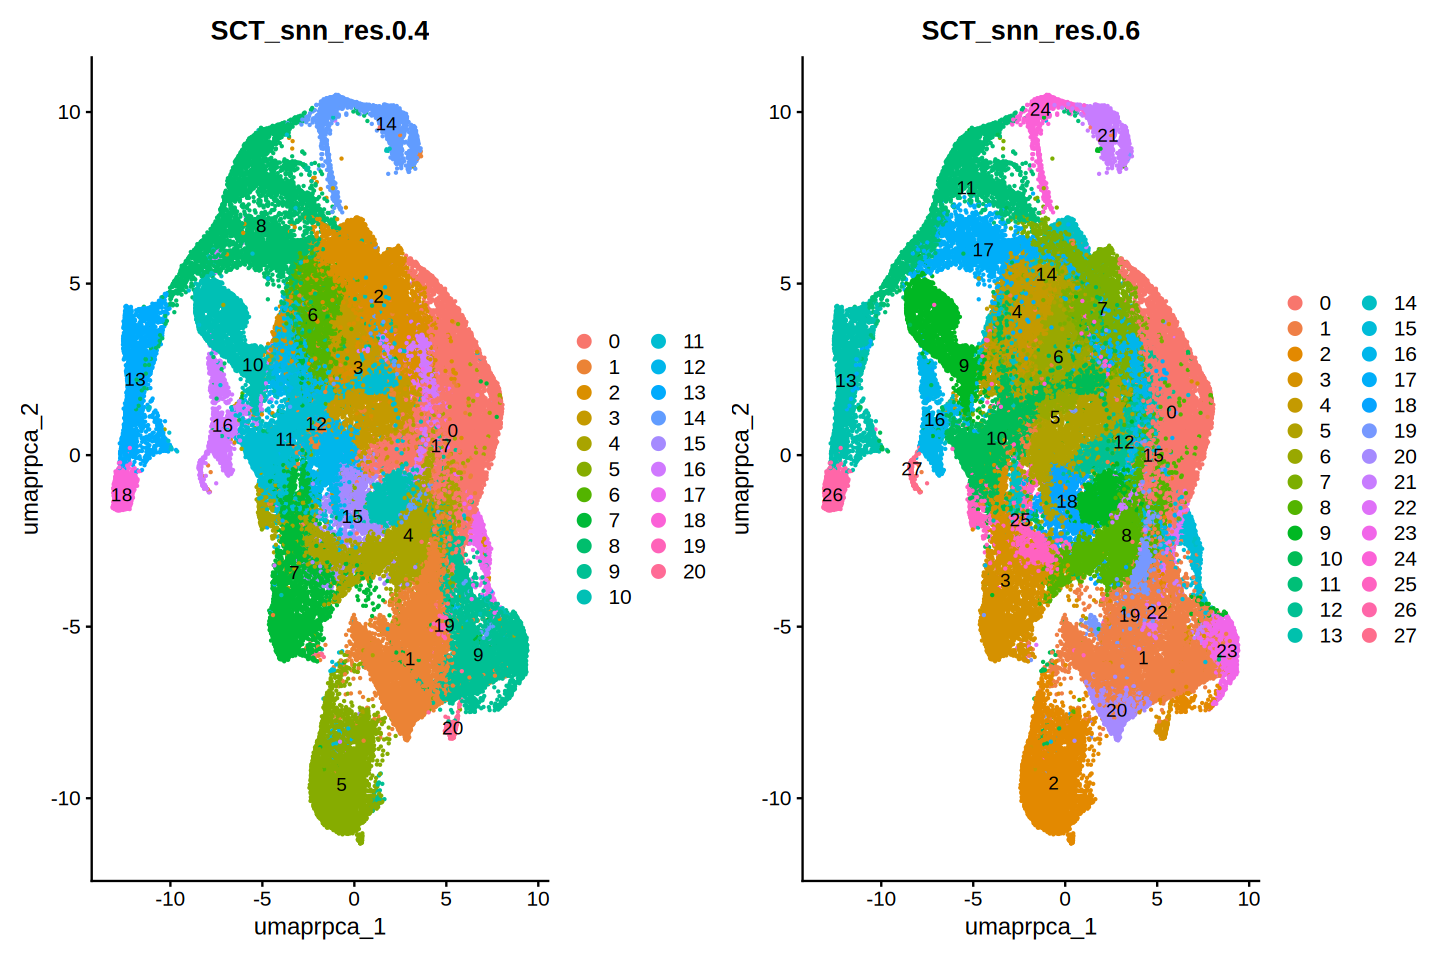

In [24]:
options(repr.plot.width = 12, repr.plot.height = 8)    
p1 <- DimPlot(myeloid, reduction = 'umap.rpca', group.by = 'SCT_snn_res.0.4', label = TRUE)
p2 <- DimPlot(myeloid, reduction = 'umap.rpca', group.by = 'SCT_snn_res.0.6', label = TRUE)

p1 + p2 

# Find Markers

In [4]:
myeloid <- PrepSCTFindMarkers(myeloid, assay = 'SCT', verbose = TRUE)

Found 9 SCT models. Recorrecting SCT counts using minimum median counts: 1059



In [5]:
Idents(myeloid) <- 'SCT_snn_res.0.1'

rpca_markers_0.1 <- FindAllMarkers(myeloid, assay = 'SCT', only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, test.use = 'wilcox')

rpca_markers_0.1 <- rpca_markers_0.1 |> arrange(desc(avg_log2FC))

# Save for 0.1 resolution
write.csv(rpca_markers_0.1, '/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/rpca/markers/rpca_myeloid_markers_0.1.csv')

# For Resolution 0.2 
Idents(myeloid) <- 'SCT_snn_res.0.2'

rpca_markers_0.2 <- FindAllMarkers(myeloid, assay = 'SCT', only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, test.use = 'wilcox')

rpca_markers_0.2 <- rpca_markers_0.2 |> arrange(desc(avg_log2FC))

# Save for 0.2 resolution
write.csv(rpca_markers_0.2, '/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/rpca/markers/rpca_myeloid_markers_0.2.csv')


Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12



In [20]:
# For Resolution 0.4 
Idents(myeloid) <- 'SCT_snn_res.0.4'

rpca_markers_0.4 <- FindAllMarkers(myeloid, assay = 'SCT', only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, test.use = 'wilcox')

rpca_markers_0.4 <- rpca_markers_0.4 |> arrange(desc(avg_log2FC))

write.csv(rpca_markers_0.4, '/mnt/18T/chibao/gliomas/data_official/02_myeloid/new/rpca/markers/rpca_myeloid_markers_0.4.csv')

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 20



# Dot Plot

In [6]:
# Range
# top_markers <- cluster1$gene[1:15]
# top_markers <- c('TMEM119', 'TREM2', 'P2RY12', "CX3CR1", "GPR34", "SALL1", "CSF1R")
top_markers <- c("CD74", "CD14", "CD163", "FCGR3B")
# top_markers <- c("APC", "CNTNAP2", "CNP", "MAG", "MBP", "MOG", "PLP1", "RTN4", "OMG", "TPPP")


# Flatten the markers for DotPlot
markers_genes <- unlist(top_markers)
markers_genes <- make.unique(markers_genes)

# Set factor levels in the order of your original markers vector
markers_genes <- factor(markers_genes, levels = markers_genes)

# Create a mapping from gene -> "Cluster0:Gene" label
label_map <- setNames(
  paste0("ClusterX:", markers_genes),
  markers_genes
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


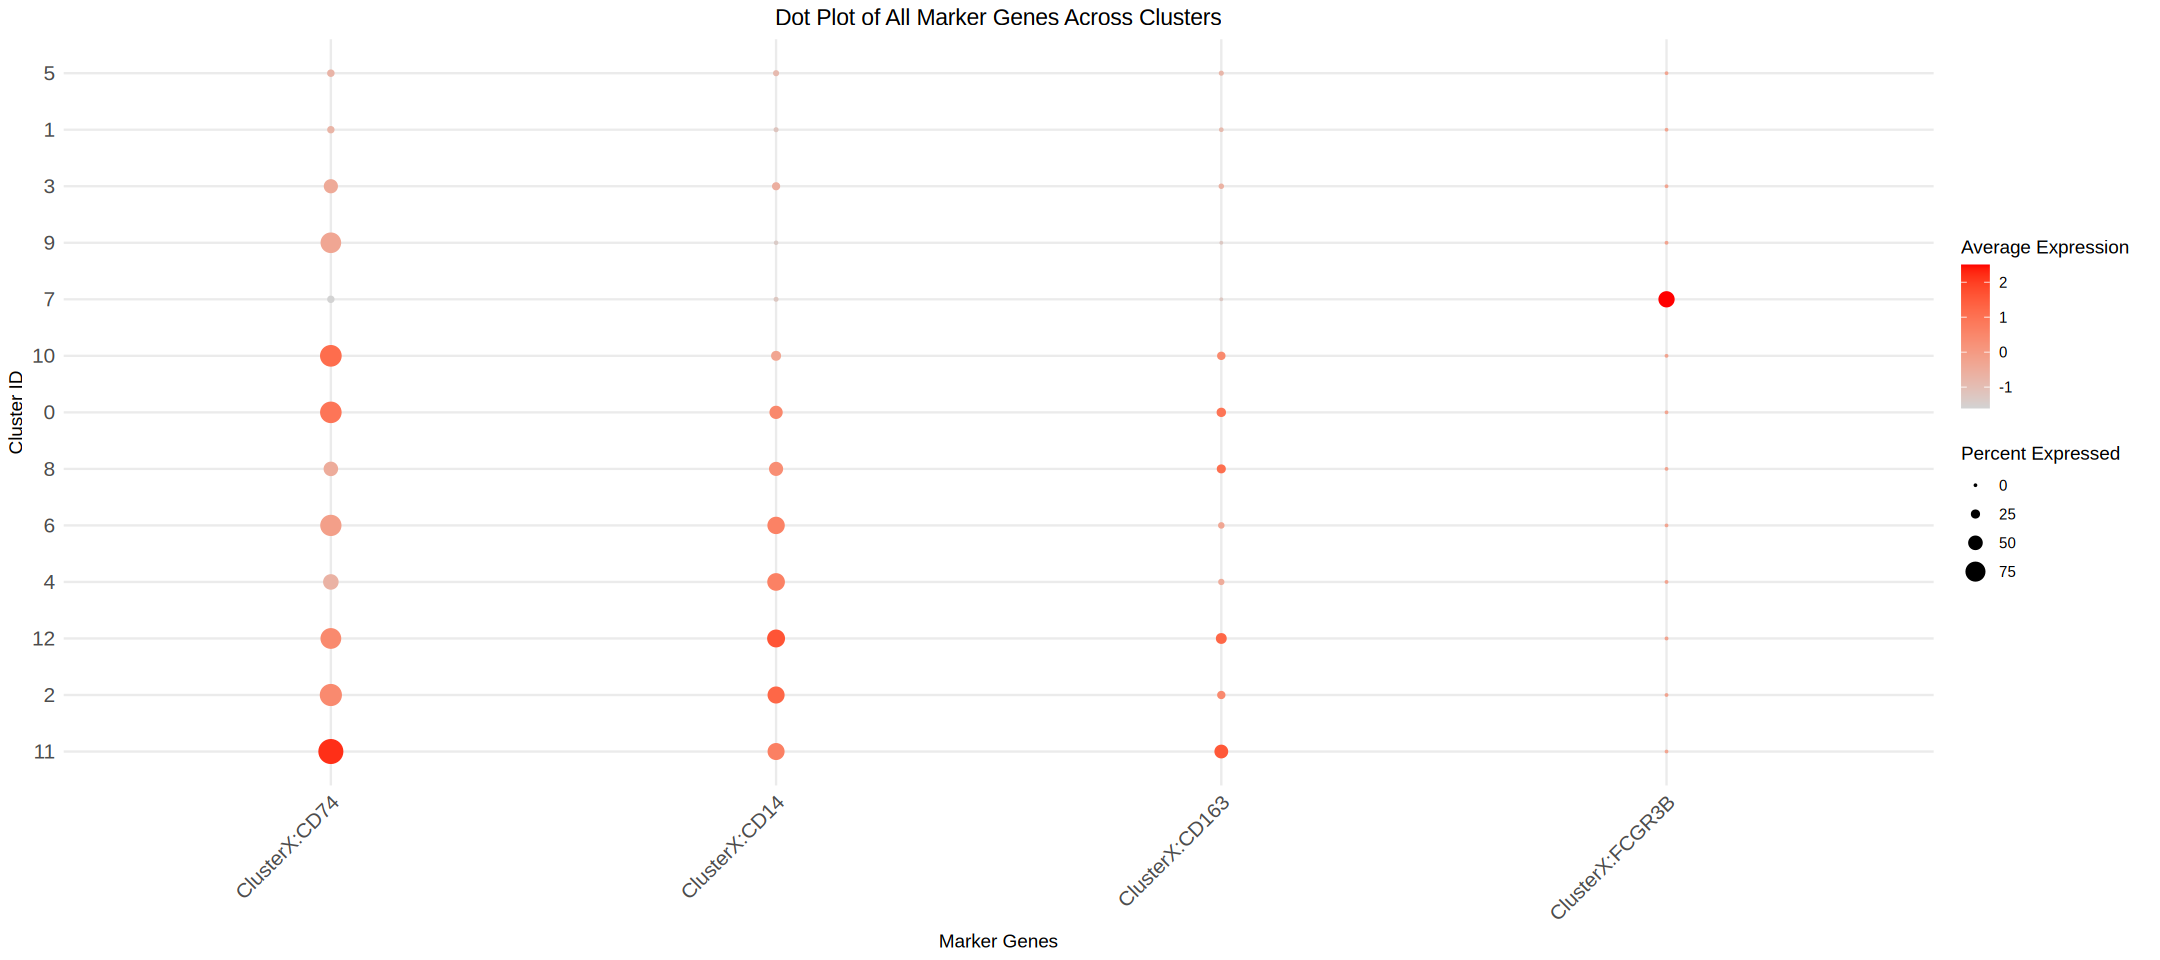

In [7]:
options(repr.plot.width = 18, repr.plot.height = 8)
Idents(myeloid) <- 'SCT_snn_res.0.2' # 0.2 or 0.1 
DotPlot(myeloid, features = markers_genes, cluster.idents = TRUE) +
  scale_color_gradient(low = "lightgrey", high = "red") +
  theme_minimal() +
  xlab("Marker Genes") +
  ylab("Cluster ID") +
  ggtitle("Dot Plot of All Marker Genes Across Clusters") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    plot.title  = element_text(hjust = 0.5)
  ) +
  # Override labels so "CD3D" is displayed as "T_cells:CD3D", etc.
  scale_x_discrete(labels = label_map)

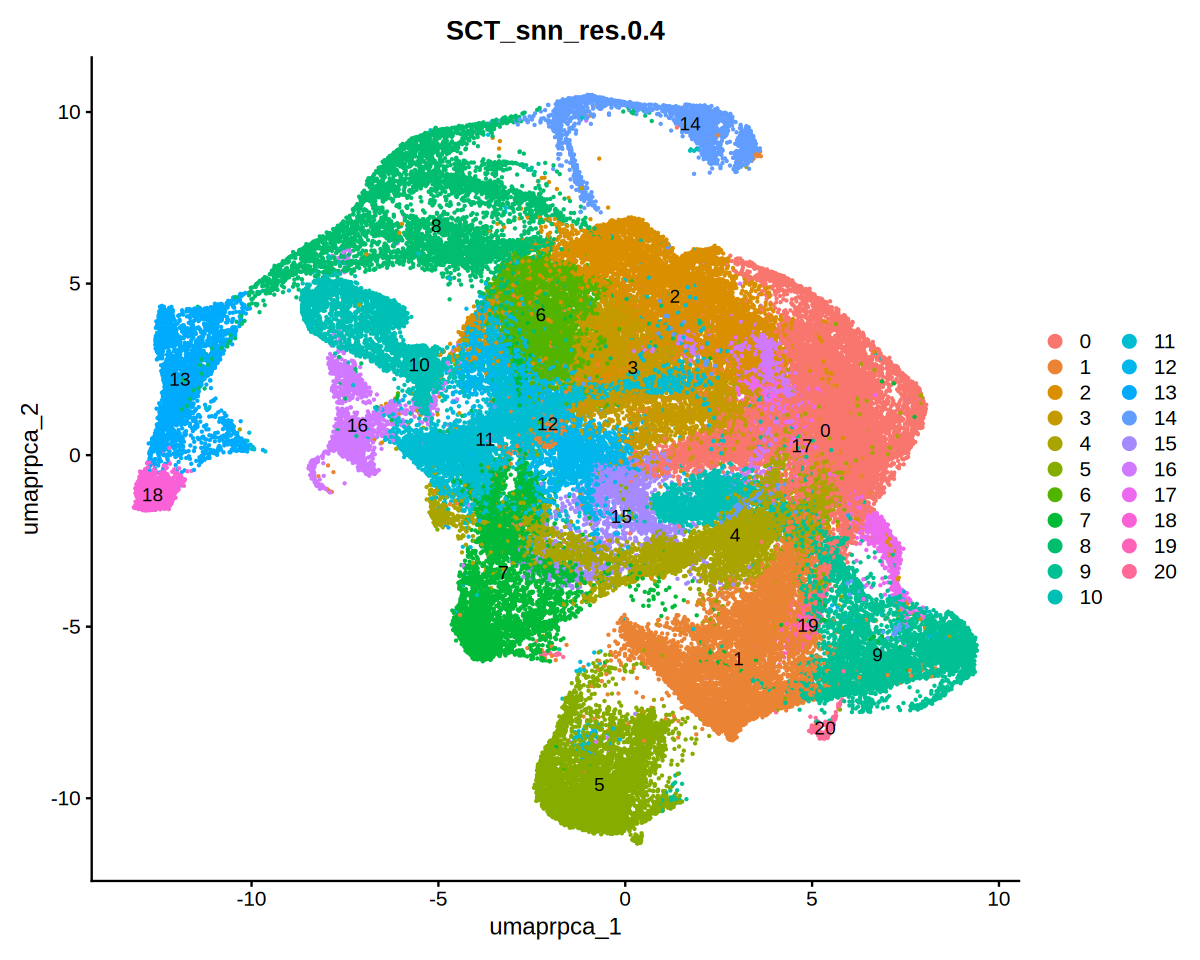

In [25]:
options(repr.plot.width = 10, repr.plot.height = 8)
p1

# Feature Plot

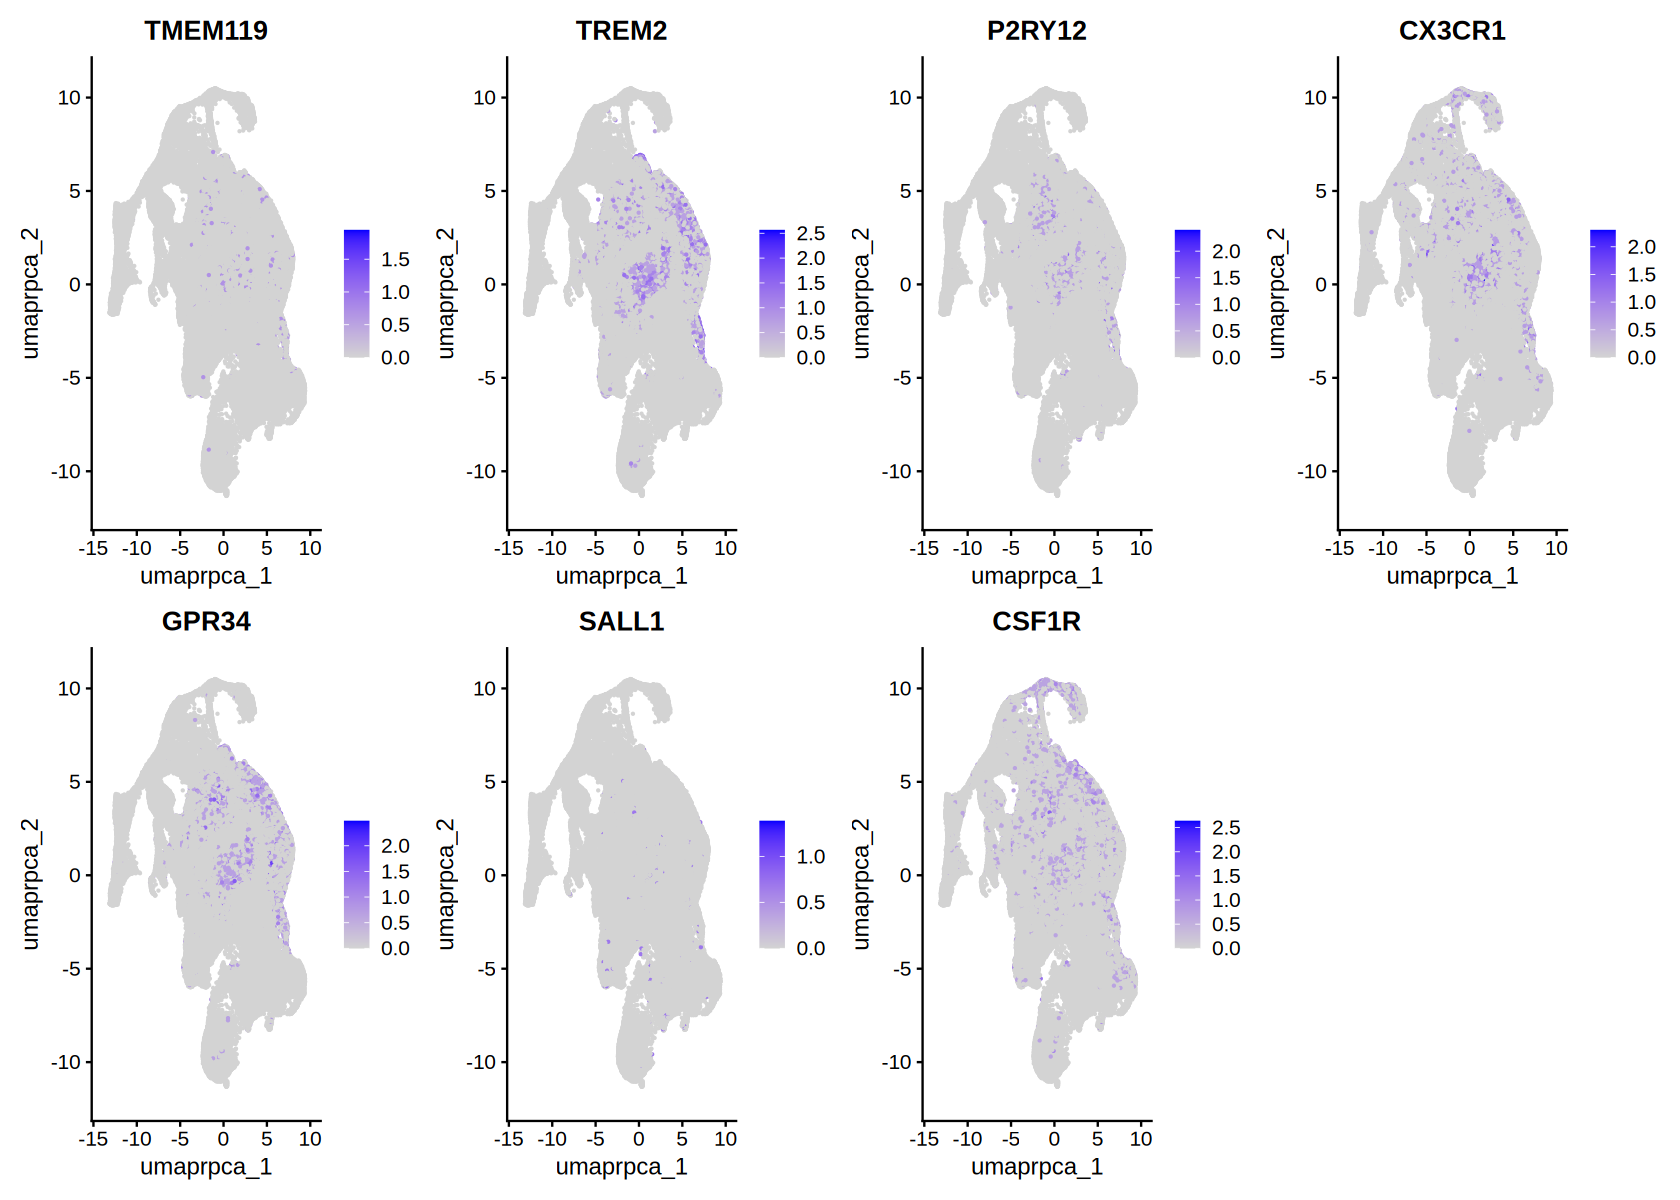

In [19]:
options(repr.plot.width = 14, repr.plot.height = 10)
FeaturePlot(myeloid, features = c('TMEM119', 'TREM2', 'P2RY12', "CX3CR1", "GPR34", "SALL1", "CSF1R"), reduction = 'umap.rpca', ncol = 4)

# GO Analysis

In [26]:
cluster0_genes <- rpca_markers_0.4 |> filter(cluster == 0 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster1_genes <- rpca_markers_0.4 |> filter(cluster == 1 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster2_genes <- rpca_markers_0.4 |> filter(cluster == 2 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster3_genes <- rpca_markers_0.4 |> filter(cluster == 3 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster4_genes <- rpca_markers_0.4 |> filter(cluster == 4 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster5_genes <- rpca_markers_0.4 |> filter(cluster == 5 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster6_genes <- rpca_markers_0.4 |> filter(cluster == 6 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster7_genes <- rpca_markers_0.4 |> filter(cluster == 7 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster8_genes <- rpca_markers_0.4 |> filter(cluster == 8 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster9_genes <- rpca_markers_0.4 |> filter(cluster == 9 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster10_genes <- rpca_markers_0.4 |> filter(cluster == 10 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster11_genes <- rpca_markers_0.4 |> filter(cluster == 11 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster12_genes <- rpca_markers_0.4 |> filter(cluster == 12 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster13_genes <- rpca_markers_0.4 |> filter(cluster == 13 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster14_genes <- rpca_markers_0.4 |> filter(cluster == 14 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster15_genes <- rpca_markers_0.4 |> filter(cluster == 15 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster16_genes <- rpca_markers_0.4 |> filter(cluster == 16 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster17_genes <- rpca_markers_0.4 |> filter(cluster == 17 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster18_genes <- rpca_markers_0.4 |> filter(cluster == 18 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster19_genes <- rpca_markers_0.4 |> filter(cluster == 19 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster20_genes <- rpca_markers_0.4 |> filter(cluster == 20 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)

In [38]:
# Convert gene symbols to Entrez IDs
entrez_ids <- bitr(
    cluster1_genes,
    fromType = "SYMBOL", 
    toType = "ENTREZID", 
    OrgDb = org.Hs.eg.db)

'select()' returned 1:1 mapping between keys and columns



In [39]:
# GO enrichment analysis
go_result <- enrichGO(gene = entrez_ids$ENTREZID,
                                         OrgDb = org.Hs.eg.db,
                                         ont = "BP",  # Biological Process
                                         pAdjustMethod = "BH",
                                         pvalueCutoff = 0.05,
                                         qvalueCutoff = 0.05
                                         )

Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


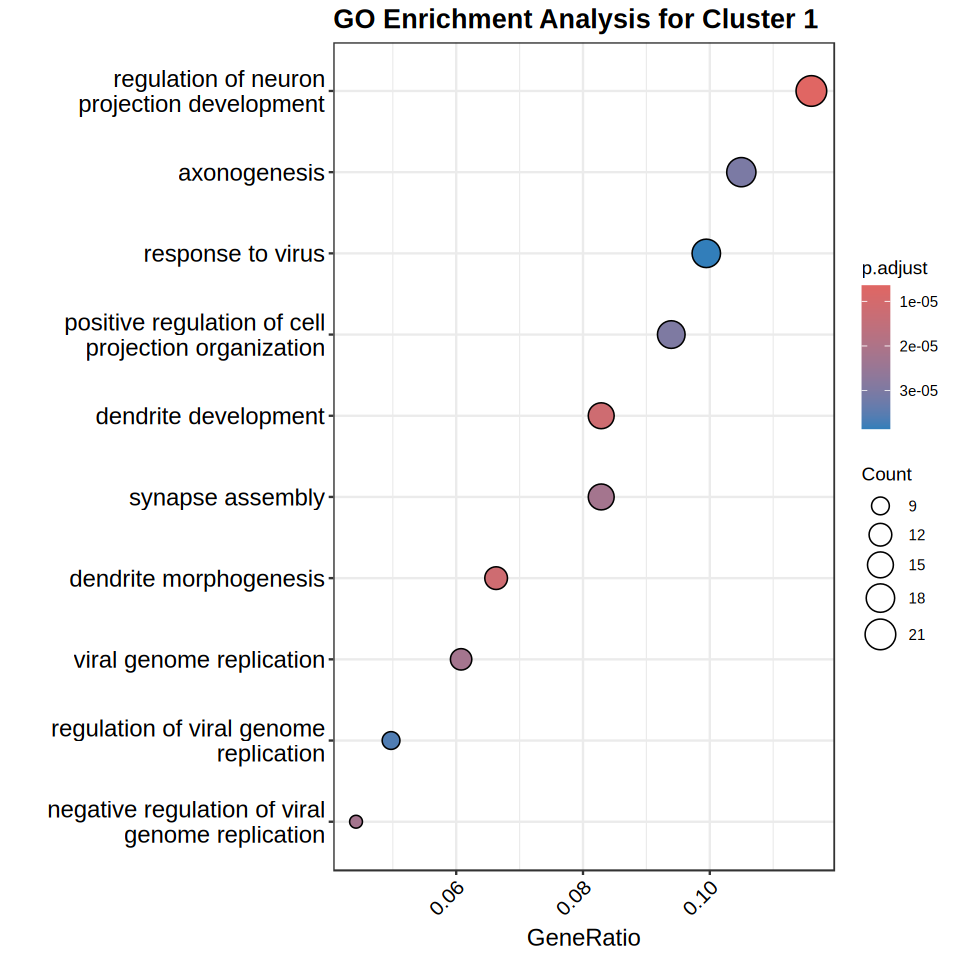

In [40]:
# Visualize GO results
options(repr.plot.width = 8, repr.plot.height = 8)
dotplot(go_result, showCategory = 10) + 
    ggtitle("GO Enrichment Analysis for Cluster 1") +
    theme(plot.title = element_text(size = 16, face = "bold"),
          axis.text.y = element_text(size = 14),
          axis.text.x = element_text(size = 12, angle = 45, hjust = 1),
          axis.title = element_text(size = 14)) +
    scale_size(range = c(3, 8))

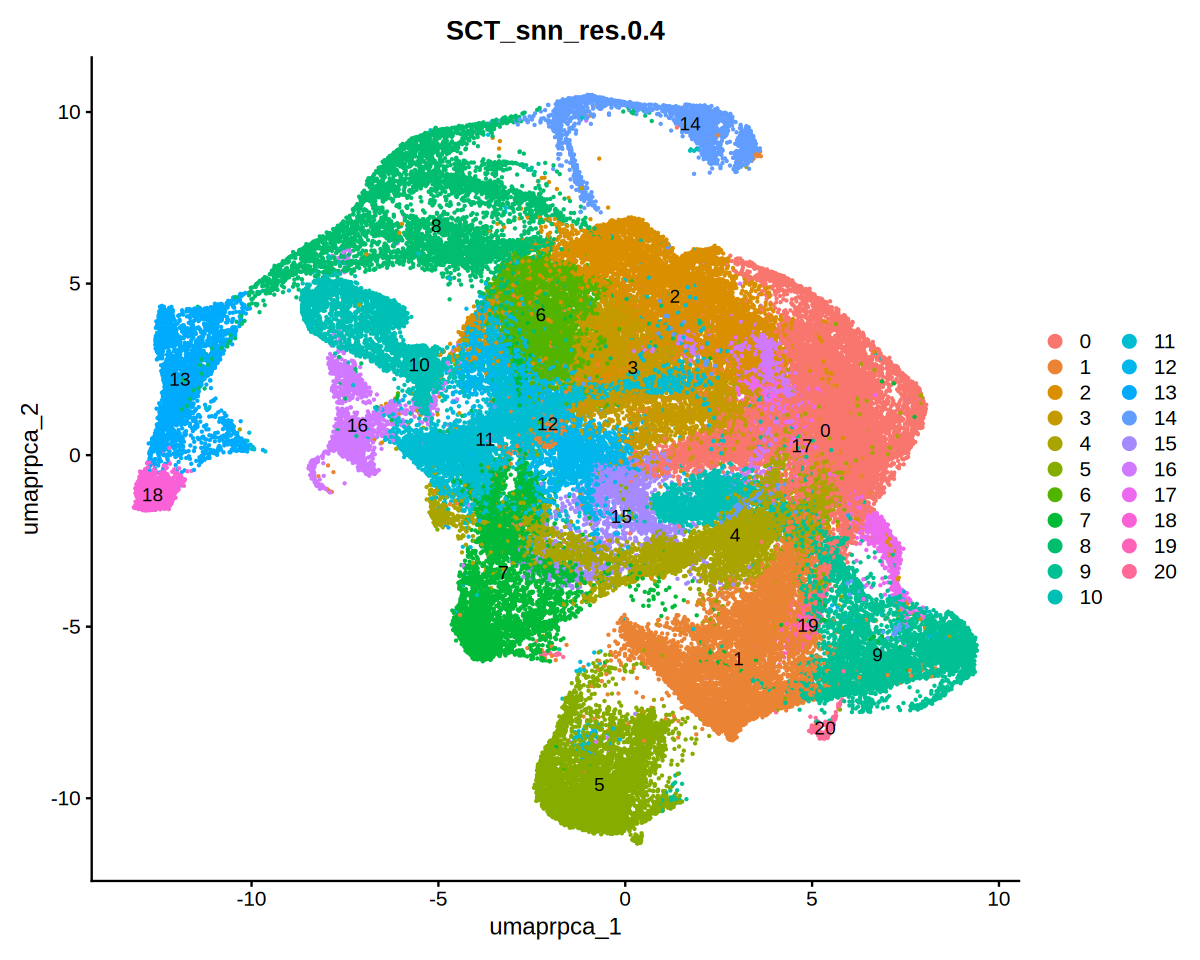

In [31]:
options(repr.plot.width = 10, repr.plot.height = 8)
p1

In [41]:
# set identity to desired resolution, e.g. 0.4
Idents(myeloid) <- 'SCT_snn_res.0.4'

# count cells in each cluster
table(Idents(myeloid))


    0     1     2     3     4     5     6     7     8     9    10    11    12 
11106  7787  7442  5659  5474  5468  4959  4914  4908  4799  4596  4404  3642 
   13    14    15    16    17    18    19    20 
 2798  2581  2521  2478  2366  1060   866   158 

In [ ]:
# 0, 17: MG-TAM
# 9: IFN_TAM